<a href="https://colab.research.google.com/github/maheshkumar30/Intellipaat-DataScience/blob/main/RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df =pd.read_csv("/content/AirPassengers.csv")

In [ ]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
data = df['#Passengers'].values.reshape(-1,1)

In [ ]:
data

array([[112],
       [118],
       [132],
       [129],
       [121],
       [135],
       [148],
       [148],
       [136],
       [119],
       [104],
       [118],
       [115],
       [126],
       [141],
       [135],
       [125],
       [149],
       [170],
       [170],
       [158],
       [133],
       [114],
       [140],
       [145],
       [150],
       [178],
       [163],
       [172],
       [178],
       [199],
       [199],
       [184],
       [162],
       [146],
       [166],
       [171],
       [180],
       [193],
       [181],
       [183],
       [218],
       [230],
       [242],
       [209],
       [191],
       [172],
       [194],
       [196],
       [196],
       [236],
       [235],
       [229],
       [243],
       [264],
       [272],
       [237],
       [211],
       [180],
       [201],
       [204],
       [188],
       [235],
       [227],
       [234],
       [264],
       [302],
       [293],
       [259],
       [229],
       [203],
      

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
data_scaled[:5]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

In [ ]:
len(data_scaled)

144

In [ ]:
x = []
y = []
for i in range(len(data_scaled)-12):
    x.append(data_scaled[i : i+12])   # Consecutive 12 month data(sequence)
    y.append(data_scaled[i+12])       # next followed data (Next jan)

In [ ]:
len(x),len(y)

(132, 132)

In [ ]:
x = torch.tensor(x,dtype = torch.float32)
y = torch.tensor(y,dtype = torch.float32)

In [ ]:
x.dtype

torch.float32

In [ ]:
# We will create class (Arch) --> RNN
class RNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1,hidden_size=16,batch_first=True)
        self.fc = nn.Linear(16,1)
    def forward(self,x):
        out,hidden = self.rnn(x)
        finalOut = out[:,-1, : ]
        print(f"This is the last step of every batch of 3D tensor(1: Batch,2: outputs,3 : Hidden feature){finalOut}")
        linOut = self.fc(finalOut)
        return linOut

In [ ]:
model = RNN()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)
loss = nn.MSELoss()

In [ ]:
epoch = 100
for i in range(epoch):
    optimizer.zero_grad()           # We have clear old gradients --> so that we can see errors

    preds = model(x)
    lossVal = loss(preds,y)
    lossVal.backward()

    optimizer.step()

    if (i+1) %10 == 0:
        print(f"Epoch:{(i+1)/epoch},Loss: {lossVal.item()}")

This is the last step of every batch of 3D tensor(1: Batch,2: outputs,3 : Hidden feature)tensor([[-0.1427, -0.0617, -0.2117,  ..., -0.2692, -0.1428, -0.2277],
        [-0.1389, -0.0629, -0.2116,  ..., -0.2703, -0.1420, -0.2275],
        [-0.1439, -0.0594, -0.2095,  ..., -0.2696, -0.1459, -0.2302],
        ...,
        [-0.2400,  0.1340, -0.0727,  ..., -0.1886, -0.3346, -0.4992],
        [-0.2362,  0.1142, -0.0898,  ..., -0.1922, -0.3121, -0.4738],
        [-0.2132,  0.0840, -0.1123,  ..., -0.2040, -0.2811, -0.4426]],
       grad_fn=<SelectBackward0>)
This is the last step of every batch of 3D tensor(1: Batch,2: outputs,3 : Hidden feature)tensor([[-0.1961,  0.0347, -0.1691,  ..., -0.2250, -0.1029, -0.1596],
        [-0.1926,  0.0338, -0.1685,  ..., -0.2261, -0.1020, -0.1588],
        [-0.1976,  0.0376, -0.1662,  ..., -0.2253, -0.1060, -0.1615],
        ...,
        [-0.3002,  0.2342, -0.0266,  ..., -0.1439, -0.2914, -0.4403],
        [-0.2946,  0.2126, -0.0460,  ..., -0.1482, -0.2694, -

In [ ]:
preds

tensor([[0.0422],
        [0.0425],
        [0.0509],
        [0.0723],
        [0.0716],
        [0.0580],
        [0.0837],
        [0.1191],
        [0.1269],
        [0.1147],
        [0.0851],
        [0.0555],
        [0.0778],
        [0.0919],
        [0.0958],
        [0.1305],
        [0.1267],
        [0.1317],
        [0.1460],
        [0.1743],
        [0.1839],
        [0.1685],
        [0.1405],
        [0.1157],
        [0.1319],
        [0.1433],
        [0.1520],
        [0.1707],
        [0.1635],
        [0.1620],
        [0.2057],
        [0.2346],
        [0.2532],
        [0.2247],
        [0.1956],
        [0.1704],
        [0.1870],
        [0.1949],
        [0.1918],
        [0.2378],
        [0.2544],
        [0.2470],
        [0.2651],
        [0.2989],
        [0.3173],
        [0.2830],
        [0.2439],
        [0.2017],
        [0.2113],
        [0.2183],
        [0.1945],
        [0.2399],
        [0.2501],
        [0.2520],
        [0.2926],
        [0

In [ ]:
answer = scaler.inverse_transform(preds.detach().numpy())
answer[:5]

array([[125.876434],
       [126.01727 ],
       [130.36937 ],
       [141.45201 ],
       [141.08199 ]], dtype=float32)

In [ ]:
originalData = scaler.inverse_transform(y.numpy()) # no gradients we applied for y
originalData[:5]

array([[115.],
       [126.],
       [141.],
       [135.],
       [125.]], dtype=float32)

In [ ]:
import matplotlib.pyplot as plt

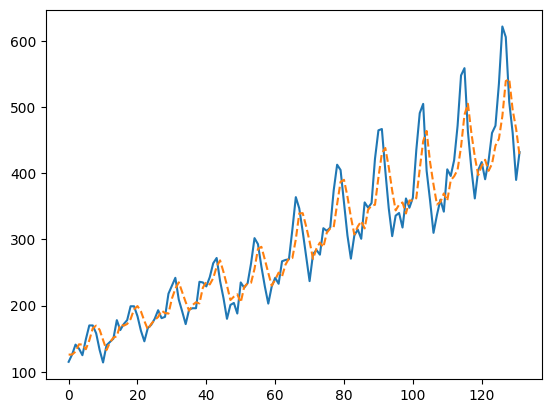

In [ ]:
plt.plot(originalData)
plt.plot(answer,linestyle="--")
plt.show()

#**LSTM**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("AirPassengers.csv")

data = df["#Passengers"].values.astype(float)
data = data.reshape(-1,1)

In [ ]:
data

array([[112.],
       [118.],
       [132.],
       [129.],
       [121.],
       [135.],
       [148.],
       [148.],
       [136.],
       [119.],
       [104.],
       [118.],
       [115.],
       [126.],
       [141.],
       [135.],
       [125.],
       [149.],
       [170.],
       [170.],
       [158.],
       [133.],
       [114.],
       [140.],
       [145.],
       [150.],
       [178.],
       [163.],
       [172.],
       [178.],
       [199.],
       [199.],
       [184.],
       [162.],
       [146.],
       [166.],
       [171.],
       [180.],
       [193.],
       [181.],
       [183.],
       [218.],
       [230.],
       [242.],
       [209.],
       [191.],
       [172.],
       [194.],
       [196.],
       [196.],
       [236.],
       [235.],
       [229.],
       [243.],
       [264.],
       [272.],
       [237.],
       [211.],
       [180.],
       [201.],
       [204.],
       [188.],
       [235.],
       [227.],
       [234.],
       [264.],
       [30

**Normalize Data**

Neural networks work better with scaled values.

In [ ]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

**Create Sequential Dataset**

LSTM needs time sequences.

Example:
Use 12 months → predict next month

In [ ]:
def create_dataset(dataset, time_step=12):

    X = []
    y = []

    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step),0])
        y.append(dataset[i+time_step,0])

    return np.array(X), np.array(y)

**Convert to PyTorch Tensors**

In [ ]:
time_step = 12

X, y = create_dataset(data_scaled, time_step)

In [ ]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

X = X.unsqueeze(-1)

**Build LSTM Model**

In [ ]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(input_size=1,
                            hidden_size=50,
                            batch_first=True)

        self.fc = nn.Linear(50,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

**Initialize Model**

In [ ]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

**Train Model**

In [ ]:
epochs = 200

for epoch in range(epochs):

    preds = model(X)

    loss = criterion(preds, y.unsqueeze(1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.2466173768043518
Epoch: 20 Loss: 0.024961067363619804
Epoch: 40 Loss: 0.010334680788218975
Epoch: 60 Loss: 0.007634006440639496
Epoch: 80 Loss: 0.007026358507573605
Epoch: 100 Loss: 0.0063766418024897575
Epoch: 120 Loss: 0.0051482850685715675
Epoch: 140 Loss: 0.006079144310206175
Epoch: 160 Loss: 0.0025501318741589785
Epoch: 180 Loss: 0.0023854596074670553


**Make Predictions**

In [ ]:
pred = model(X).detach().numpy()

pred = scaler.inverse_transform(pred)

real = scaler.inverse_transform(y.reshape(-1,1))

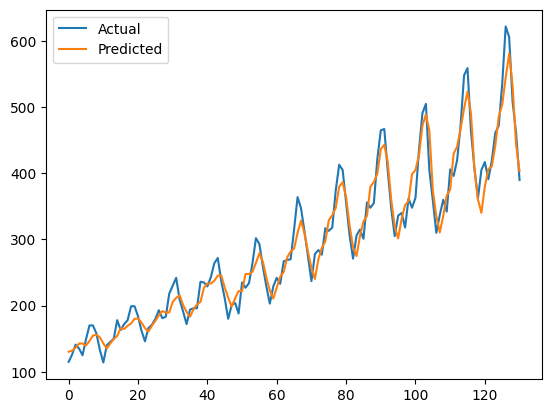

In [ ]:
plt.plot(real, label="Actual")
plt.plot(pred, label="Predicted")

plt.legend()
plt.show()